In [16]:
import mne

eye_open_raw_bdf = mne.io.read_raw_bdf("../dataset/open_UnicornRawDataRecorder_15_07_2026_16_04_18.bdf")
eye_close_raw_bdf = mne.io.read_raw_bdf("../dataset/close_UnicornRawDataRecorder_15_07_2026_16_09_47.bdf")

eye_close_raw_bdf.rename_channels(
    {
        "EXG 1": "Fz",
        "EXG 2": "C3",
        "EXG 3": "Cz",
        "EXG 4": "C4",
        "EXG 5": "Pz",
        "EXG 6": "PO7",
        "EXG 7": "POz",
        "EXG 8": "PO8",
    }
)

eye_open_raw_bdf.rename_channels(
    {
        "EXG 1": "Fz",
        "EXG 2": "C3",
        "EXG 3": "Cz",
        "EXG 4": "C4",
        "EXG 5": "Pz",
        "EXG 6": "PO7",
        "EXG 7": "POz",
        "EXG 8": "PO8",
    }
)

eye_close_raw_bdf.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})
eye_open_raw_bdf.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})

Extracting BDF parameters from ../dataset/open_UnicornRawDataRecorder_15_07_2026_16_04_18.bdf...
Setting channel info structure...
Creating raw.info structure...
Extracting BDF parameters from ../dataset/close_UnicornRawDataRecorder_15_07_2026_16_09_47.bdf...
Setting channel info structure...
Creating raw.info structure...


C:\Users\akila\AppData\Local\Temp\ipykernel_18312\4184390479.py:32: RuntimeWarning: The unit for channel(s) BAT, CNT, DT, SATURATION, VALID has changed from V to NA.
  eye_close_raw_bdf.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})
C:\Users\akila\AppData\Local\Temp\ipykernel_18312\4184390479.py:33: RuntimeWarning: The unit for channel(s) BAT, CNT, DT, SATURATION, VALID has changed from V to NA.
  eye_open_raw_bdf.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})


<RawBDF | open_UnicornRawDataRecorder_15_07_2026_16_04_18.bdf, 14 x 76175 (304.7 s), ~15 KiB, data not loaded>

In [32]:
EPOCH_DURATION = 1

epochs_open = mne.make_fixed_length_epochs(
    eye_open_raw_bdf, duration=EPOCH_DURATION, preload=True, overlap=0.0
)
open_data = epochs_open.get_data(picks="eeg")  # (n_epochs, n_channels, n_times)
epochs_close = mne.make_fixed_length_epochs(
    eye_close_raw_bdf, duration=EPOCH_DURATION, preload=True, overlap=0.0
)
close_data = epochs_close.get_data(picks="eeg")  # (n_epochs, n_channels, n_times)

sfreq = epochs_open.info["sfreq"]
ch_names = [eye_open_raw_bdf.ch_names[i] for i in mne.pick_types(eye_open_raw_bdf.info, eeg=True)]

print(f"open_data shape:  {open_data.shape}")
print(f"close_data shape: {close_data.shape}")
print(f"sfreq: {sfreq} Hz")
print(f"EEG channels: {ch_names}")

Not setting metadata
304 matching events found
No baseline correction applied
0 projection items activated
Loading data for 304 events and 250 original time points ...
0 bad epochs dropped
Not setting metadata
305 matching events found
No baseline correction applied
0 projection items activated
Loading data for 305 events and 250 original time points ...
0 bad epochs dropped
open_data shape:  (304, 8, 250)
close_data shape: (305, 8, 250)
sfreq: 250.0 Hz
EEG channels: ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'POz', 'PO8']


In [33]:
import numpy as np
import pywt
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

RANDOM_STATE = 42
BAND_LOW, BAND_HIGH = 7.0, 13.0
N_BLOCKS = 5

n_open = open_data.shape[0]
n_close = close_data.shape[0]
edges_open = np.linspace(0, n_open, N_BLOCKS + 1, dtype=int)
edges_close = np.linspace(0, n_close, N_BLOCKS + 1, dtype=int)

results = {}  # method_name -> list of fold accuracies

In [34]:
fold_accs_bandpower = []

for fold in range(N_BLOCKS):
    open_test = open_data[edges_open[fold]:edges_open[fold+1]]
    close_test = close_data[edges_close[fold]:edges_close[fold+1]]
    open_train = np.concatenate(
        [open_data[edges_open[i]:edges_open[i+1]] for i in range(N_BLOCKS) if i != fold], axis=0
    )
    close_train = np.concatenate(
        [close_data[edges_close[i]:edges_close[i+1]] for i in range(N_BLOCKS) if i != fold], axis=0
    )

    # --- train features ---
    X_train = []
    y_train = []
    for data, label in [(open_train, 0), (close_train, 1)]:
        for e in range(data.shape[0]):
            feats = []
            for c in range(data.shape[1]):
                freqs, psd = welch(data[e, c, :], fs=sfreq, nperseg=min(256, data.shape[-1]))
                mask = (freqs >= BAND_LOW) & (freqs <= BAND_HIGH)
                feats.append(np.log1p(psd[mask].mean()))
            X_train.append(feats)
            y_train.append(label)
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    # --- test features ---
    X_test = []
    y_test = []
    for data, label in [(open_test, 0), (close_test, 1)]:
        for e in range(data.shape[0]):
            feats = []
            for c in range(data.shape[1]):
                freqs, psd = welch(data[e, c, :], fs=sfreq, nperseg=min(256, data.shape[-1]))
                mask = (freqs >= BAND_LOW) & (freqs <= BAND_HIGH)
                feats.append(np.log1p(psd[mask].mean()))
            X_test.append(feats)
            y_test.append(label)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    scaler = StandardScaler().fit(X_train)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(scaler.transform(X_train), y_train)
    acc = accuracy_score(y_test, clf.predict(scaler.transform(X_test)))
    fold_accs_bandpower.append(acc)
    print(f"Fold {fold}: {acc:.3f}")

fold_accs_bandpower = np.array(fold_accs_bandpower)
results["Bandpower"] = fold_accs_bandpower
print(f"\nBandpower: {fold_accs_bandpower.mean():.3f} +/- {fold_accs_bandpower.std():.3f}")

Fold 0: 0.983
Fold 1: 0.992
Fold 2: 0.992
Fold 3: 0.967
Fold 4: 0.934

Bandpower: 0.974 +/- 0.022


In [35]:
wavelet = "db6"
n_times = open_data.shape[-1]
nyquist = sfreq / 2.0
max_level = pywt.dwt_max_level(n_times, pywt.Wavelet(wavelet).dec_len)

# pick the DWT level whose band best overlaps 7-13 Hz
best_level, best_overlap = 1, -1
for lvl in range(1, max_level + 1):
    f_lo = nyquist / (2 ** lvl)
    f_hi = nyquist / (2 ** (lvl - 1))
    overlap = min(f_hi, BAND_HIGH) - max(f_lo, BAND_LOW)
    if overlap > best_overlap:
        best_overlap, best_level = overlap, lvl
print(f"Using DWT level {best_level} ({nyquist/2**best_level:.2f}-{nyquist/2**(best_level-1):.2f} Hz)")

fold_accs_dwt = []

for fold in range(N_BLOCKS):
    open_test = open_data[edges_open[fold]:edges_open[fold+1]]
    close_test = close_data[edges_close[fold]:edges_close[fold+1]]
    open_train = np.concatenate(
        [open_data[edges_open[i]:edges_open[i+1]] for i in range(N_BLOCKS) if i != fold], axis=0
    )
    close_train = np.concatenate(
        [close_data[edges_close[i]:edges_close[i+1]] for i in range(N_BLOCKS) if i != fold], axis=0
    )

    X_train = []
    y_train = []
    for data, label in [(open_train, 0), (close_train, 1)]:
        for e in range(data.shape[0]):
            feats = []
            for c in range(data.shape[1]):
                coeffs = pywt.wavedec(data[e, c, :], wavelet, level=max_level)
                detail = coeffs[max_level - best_level + 1]
                feats.append(np.log1p(np.sum(detail ** 2)))
            X_train.append(feats)
            y_train.append(label)
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    X_test = []
    y_test = []
    for data, label in [(open_test, 0), (close_test, 1)]:
        for e in range(data.shape[0]):
            feats = []
            for c in range(data.shape[1]):
                coeffs = pywt.wavedec(data[e, c, :], wavelet, level=max_level)
                detail = coeffs[max_level - best_level + 1]
                feats.append(np.log1p(np.sum(detail ** 2)))
            X_test.append(feats)
            y_test.append(label)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    scaler = StandardScaler().fit(X_train)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(scaler.transform(X_train), y_train)
    acc = accuracy_score(y_test, clf.predict(scaler.transform(X_test)))
    fold_accs_dwt.append(acc)
    print(f"Fold {fold}: {acc:.3f}")

fold_accs_dwt = np.array(fold_accs_dwt)
results["DWT"] = fold_accs_dwt
print(f"\nDWT: {fold_accs_dwt.mean():.3f} +/- {fold_accs_dwt.std():.3f}")

Using DWT level 4 (7.81-15.62 Hz)
Fold 0: 0.975
Fold 1: 0.984
Fold 2: 1.000
Fold 3: 0.984
Fold 4: 0.943

DWT: 0.977 +/- 0.019


In [36]:
wavelet = "db6"
maxlevel = 6
n_nodes = 2 ** maxlevel
node_bandwidth = nyquist / n_nodes
node_idx = [i for i in range(n_nodes)
            if (i + 1) * node_bandwidth > BAND_LOW and i * node_bandwidth < BAND_HIGH]
print(f"Using {len(node_idx)} WPT nodes covering "
      f"{node_idx[0]*node_bandwidth:.2f}-{(node_idx[-1]+1)*node_bandwidth:.2f} Hz")

fold_accs_wpt = []

for fold in range(N_BLOCKS):
    open_test = open_data[edges_open[fold]:edges_open[fold+1]]
    close_test = close_data[edges_close[fold]:edges_close[fold+1]]
    open_train = np.concatenate(
        [open_data[edges_open[i]:edges_open[i+1]] for i in range(N_BLOCKS) if i != fold], axis=0
    )
    close_train = np.concatenate(
        [close_data[edges_close[i]:edges_close[i+1]] for i in range(N_BLOCKS) if i != fold], axis=0
    )

    X_train = []
    y_train = []
    for data, label in [(open_train, 0), (close_train, 1)]:
        for e in range(data.shape[0]):
            feats = []
            for c in range(data.shape[1]):
                wp = pywt.WaveletPacket(data[e, c, :], wavelet, mode="symmetric", maxlevel=maxlevel)
                nodes = wp.get_level(maxlevel, order="freq")
                for i in node_idx:
                    feats.append(np.log1p(np.sum(nodes[i].data ** 2)))
            X_train.append(feats)
            y_train.append(label)
    X_train = np.array(X_train)
    y_train = np.array(y_train)

    X_test = []
    y_test = []
    for data, label in [(open_test, 0), (close_test, 1)]:
        for e in range(data.shape[0]):
            feats = []
            for c in range(data.shape[1]):
                wp = pywt.WaveletPacket(data[e, c, :], wavelet, mode="symmetric", maxlevel=maxlevel)
                nodes = wp.get_level(maxlevel, order="freq")
                for i in node_idx:
                    feats.append(np.log1p(np.sum(nodes[i].data ** 2)))
            X_test.append(feats)
            y_test.append(label)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    scaler = StandardScaler().fit(X_train)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(scaler.transform(X_train), y_train)
    acc = accuracy_score(y_test, clf.predict(scaler.transform(X_test)))
    fold_accs_wpt.append(acc)
    print(f"Fold {fold}: {acc:.3f}")

fold_accs_wpt = np.array(fold_accs_wpt)
results["WPT"] = fold_accs_wpt
print(f"\nWPT: {fold_accs_wpt.mean():.3f} +/- {fold_accs_wpt.std():.3f}")

Using 4 WPT nodes covering 5.86-13.67 Hz
Fold 0: 0.983
Fold 1: 0.992
Fold 2: 0.992
Fold 3: 0.967
Fold 4: 0.918

WPT: 0.970 +/- 0.028


Method      Mean Acc    Std       
Bandpower   0.954       0.019     
DWT         0.919       0.049     
WPT         0.947       0.017     


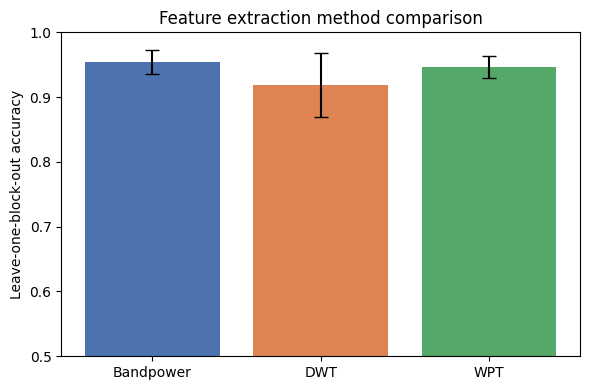

In [30]:
print(f"{'Method':<12}{'Mean Acc':<12}{'Std':<10}")
for name, accs in results.items():
    print(f"{name:<12}{accs.mean():<12.3f}{accs.std():<10.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]
ax.bar(names, means, yerr=stds, capsize=5, color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_ylabel("Leave-one-block-out accuracy")
ax.set_ylim(0.5, 1.0)
ax.set_title("Feature extraction method comparison")
plt.tight_layout()
plt.show()